# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [6]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
df.info()

(1338, 7)
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [7]:
print(df.isnull().sum())
print("Số dòng trùng lặp:", df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Số dòng trùng lặp: 1


## A.3. Invalid values

In [8]:
print(df.describe())

for col in ['sex', 'smoker', 'region']:
    print(col, df[col].unique())


print("Age âm:", (df['age'] < 0).sum())
print("BMI <= 0:", (df['bmi'] <= 0).sum())
print("Children < 0:", (df['children'] < 0).sum())
print("Charges < 0:", (df['charges'] < 0).sum())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
sex <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker <StringArray>
['yes', 'no']
Length: 2, dtype: str
region <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
Age âm: 0
BMI <= 0: 0
Children < 0: 0
Charges < 0: 0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [9]:
df['bmi_group'] = pd.cut(
    df['bmi'],
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obese'],
    right=False
)
df[['bmi', 'bmi_group']].head()


,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [10]:
for col in ['age', 'bmi', 'charges']:
    print(col)
    print(" Mean:", df[col].mean())
    print(" Median:", df[col].median())
    print(" Mode:", df[col].mode()[0])


age
 Mean: 39.20702541106129
 Median: 39.0
 Mode: 18
bmi
 Mean: 30.66339686098655
 Median: 30.4
 Mode: 32.3
charges
 Mean: 13270.422265141257
 Median: 9382.033
 Mode: 1639.5631


## Group 2 — Dispersion

In [11]:
for col in ['age', 'bmi', 'charges']:
    print(col)
    print(" Std:", df[col].std())
    print(" Variance:", df[col].var())
    print(" Range:", df[col].max() - df[col].min())
    q1, q3 = df[col].quantile([0.25, 0.75])
    print(" IQR:", q3 - q1)


age
 Std: 14.049960379216154
 Variance: 197.40138665754375
 Range: 46
 IQR: 24.0
bmi
 Std: 6.098186911679014
 Variance: 37.18788360977323
 Range: 37.17
 IQR: 8.3975
charges
 Std: 12110.011236694001
 Variance: 146652372.15285498
 Range: 62648.554110000005
 IQR: 11899.625365


## Group 3 — Location and Shape

In [12]:
for col in ['age', 'bmi', 'charges']:
    print(col)
    print(" Quartiles:", df[col].quantile([0.25, 0.5, 0.75]).tolist())
    print(" Skewness:", df[col].skew())
    print(" Kurtosis:", df[col].kurt())


age
 Quartiles: [27.0, 39.0, 51.0]
 Skewness: 0.05567251565299186
 Kurtosis: -1.2450876526418673
bmi
 Quartiles: [26.29625, 30.4, 34.69375]
 Skewness: 0.2840471105987448
 Kurtosis: -0.05073153135467834
charges
 Quartiles: [4740.28715, 9382.033, 16639.912515]
 Skewness: 1.5158796580240388
 Kurtosis: 1.6062986532967907


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [13]:
smoker_mean = df.groupby('smoker')['charges'].mean()
ratio = smoker_mean['yes'] / smoker_mean['no']
print("Tỷ lệ chi phí smoker/non-smoker:", ratio)

region_smoker = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
region_smoker['ratio'] = region_smoker['yes'] / region_smoker['no']
print(region_smoker)


Tỷ lệ chi phí smoker/non-smoker: 3.800001458298319
smoker              no           yes     ratio
region                                        
northeast  9165.531672  29673.536473  3.237514
northwest  8556.463715  30192.003182  3.528561
southeast  8032.216309  34844.996824  4.338155
southwest  8019.284513  32269.063494  4.023933


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [14]:
for grp in ['yes', 'no']:
    corr = df[df['smoker'] == grp]['bmi'].corr(df[df['smoker'] == grp]['charges'])
    print(f"Smoker={grp}: correlation BMI-charges =", corr)

Smoker=yes: correlation BMI-charges = 0.8064806070155393
Smoker=no: correlation BMI-charges = 0.0840365431283327


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [15]:
region_charges = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(region_charges)

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [16]:
children_charges = df.groupby('children')['charges'].mean()
print(children_charges)
print("Correlation children-charges:", df['children'].corr(df['charges']))


children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Correlation children-charges: 0.06799822684790469


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Correlation age-charges: 0.2990081933306476


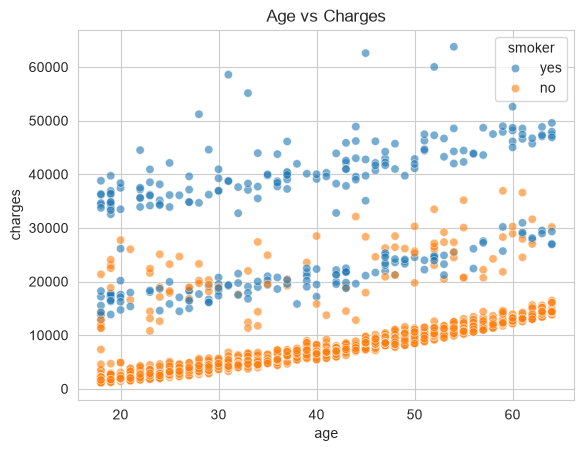

In [17]:
print("Correlation age-charges:", df['age'].corr(df['charges']))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Charges')
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Bộ dữ liệu có 1,338 bản ghi, 7 biến, không có giá trị thiếu và chỉ có đúng 1 dòng trùng lặp (không đáng kể) — dữ liệu khá sạch, không phát hiện giá trị bất thường như tuổi âm, BMI âm hay chi phí âm. Phân phối charges lệch phải rất mạnh (skewness ≈ 1.52) với mean (13,270) cao hơn hẳn median (9,382) — nghĩa là phần lớn khách hàng có chi phí thấp, trong khi một nhóm nhỏ (chủ yếu là người hút thuốc) kéo trung bình lên cao, nên khi báo cáo chi phí nên ưu tiên median hơn mean để tránh gây hiểu lầm. Đúng như dự đoán từ độ lệch đó, người hút thuốc trả chi phí trung bình cao gấp khoảng 3.8 lần người không hút thuốc, và mức chênh lệch này không đồng đều giữa các vùng, dao động từ 3.24 lần ở northeast đến 4.34 lần ở southeast. BMI có tương quan rất mạnh với chi phí ở nhóm hút thuốc (r = 0.81) nhưng gần như không đáng kể ở nhóm không hút thuốc (r = 0.08), cho thấy BMI cao chỉ thực sự tốn kém khi đi kèm với hút thuốc — một hiệu ứng tương tác (interaction effect) rõ rệt. Southeast là vùng có chi phí trung bình cao nhất (14,735), cao hơn khoảng 19% so với southwest — vùng thấp nhất (12,347), cũng là vùng có chênh lệch smoker/non-smoker lớn nhất. Ngược lại, số con cái (r = 0.068) và tuổi tác khi xét riêng lẻ (r = 0.30) chỉ có tương quan yếu với chi phí; biểu đồ age-charges cho thấy dữ liệu thực chất tách thành các dải theo tình trạng hút thuốc, khẳng định smoker là biến ẩn (confounder) chi phối mạnh nhất đến chi phí bảo hiểm trong bộ dữ liệu này.)*